# Pràctica Bloc III

In [103]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import zip_longest
from sklearn.preprocessing import StandardScaler, OneHotEncoder

train_raw, test_raw = pd.read_csv("data/train.csv"), pd.read_csv("data/test.csv")
print(f"Dimensions del dataset (train): {train_raw.shape}")
print(f"Dimensions del dataset (test): {test_raw.shape}")
train_raw.head()

Dimensions del dataset (train): (103904, 25)
Dimensions del dataset (test): (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


# Neteja i transformació de les dades

La primera columna que podem eliminar que no ens aporta absolutament res és `Unnamed: 0`, que és un identificador de les dades.

In [104]:
# eliminam columnes que no aporten informació
ignore = { "Unnamed: 0", "id" }
train_raw.drop(columns=ignore, inplace=True, errors="ignore")
test_raw.drop(columns=ignore, inplace=True, errors="ignore")
print(train_raw.columns.tolist())

['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


Una cosa important a tenir en compte és eliminar les dades invàlides ja que qualsevol operació amb una `NaN` (*Not a Number*) resultarà amb un altre `NaN`. Per fer-ho, la forma més intuitiva és veure quines columnes tenen aquests valors.

In [105]:
# comprovam quines columnes tenen valors invalids (NaNs)
train_raw.isna().sum() + test_raw.isna().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64

En aquest cas, l'única columna que conté valors `NaN` és "Arrival Delay in Minutes". Per a no perdre les 393 entrades de dades el que podem fer és reemplaçar cada un d'aquests valors invàlids amb la mitjana de tota la columna.

In [106]:
# reempleçam els NaNs per a la mitjana de la seva columna
nancol = "Arrival Delay in Minutes"
train_raw[nancol] = train_raw[nancol].fillna(train_raw[nancol].mean())
test_raw[nancol] = test_raw[nancol].fillna(test_raw[nancol].mean())
train_raw.isna().sum() + test_raw.isna().sum()

Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

També és molt important analitzar quin tipus de dades té cada columna. En aquest cas es poden separar en tres tipus:

* Dades categòriques
* Dades de nivell de satisfacció (valors en el rang $[0, 5]$)
* Dades numèriques

In [107]:
# columnes amb nivells de satisfacció [0, 5]
lvlcols = { "Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking", "Gate location",
           "Food and drink", "Online boarding", "Seat comfort", "Inflight entertainment", "On-board service",
           "Leg room service", "Baggage handling", "Checkin service", "Inflight service", "Cleanliness" }
# obtenir les columnes sense valors numèrics -> columnes categòriques
catcols = set(train_raw.select_dtypes(exclude=[np.number]).columns)
# obtenir les columnes amb valor numèrics
numcols = set(train_raw.select_dtypes(include=[np.number]).columns)
# llevam les columnes de nivel de satisfacció per a tenir-ho organitzat en tres tipus 
numcols ^= lvlcols

numcols, lvlcols, catcols = map(list, (numcols, lvlcols, catcols))

lalign = 4
sep = "-" * 80

print("Columns with categoric values")
lmax = max(len(s) for s in catcols)
catvals = { col: list(train_raw[col].unique()) for col in catcols }
print("\n".join(" " * lalign + f"{col:{lmax}s} : {catvals[col]}" for col in catcols))
print(sep)

print("Columns with satisfaction level values [0-5]")
print("\n".join(" " * lalign + col for col in lvlcols))
print(sep)

print("Columns with numeric values")
print("\n".join(" " * lalign + col for col in numcols))

Columns with categoric values
    Gender         : ['Male', 'Female']
    satisfaction   : ['neutral or dissatisfied', 'satisfied']
    Type of Travel : ['Personal Travel', 'Business travel']
    Customer Type  : ['Loyal Customer', 'disloyal Customer']
    Class          : ['Eco Plus', 'Business', 'Eco']
--------------------------------------------------------------------------------
Columns with satisfaction level values [0-5]
    Leg room service
    On-board service
    Online boarding
    Inflight entertainment
    Departure/Arrival time convenient
    Inflight wifi service
    Inflight service
    Baggage handling
    Gate location
    Seat comfort
    Cleanliness
    Ease of Online booking
    Food and drink
    Checkin service
--------------------------------------------------------------------------------
Columns with numeric values
    Flight Distance
    Departure Delay in Minutes
    Arrival Delay in Minutes
    Age


Degut a que els models no poden processar dades categòriques, és imprescindible transformar-les a dades numèriques. Per fer-ho podem utilitzar `OneHotEncoder` de scikit-learn que crea una columna nova per a cada categoria de cada columna i li assigna el valor 1 quan apareix la categoria i un 0 quan no.

Per intentar reduïr el nombre de columnes podem assignar el paràmetre `drop="if_binary"` que només crearà una columna quan només hi ha dues categories (per exèmple, el sexe del viatger). D'aquesta forma, un 1 indica la classe positiva (la que apareix al nom de la columna resultant) i un 0 la classe negativa.

In [108]:
trgcol = "satisfaction"
trgmap = {"neutral or dissatisfied": 0, "satisfied": 1}

enc = OneHotEncoder(drop="if_binary", sparse_output=False).set_output(transform="pandas")

cat_train = enc.fit_transform(train_raw[catcols].drop(columns=[trgcol], errors='ignore'))
X_train = pd.concat([train_raw.drop(columns=catcols), cat_train], axis=1)
y_train = train_raw[trgcol].map(trgmap)

cat_test = enc.transform(test_raw[catcols].drop(columns=[trgcol], errors='ignore'))
X_test = pd.concat([test_raw.drop(columns=catcols), cat_test], axis=1)
y_test = test_raw[trgcol].map(trgmap)
X_test = X_test[X_train.columns] # assegurar que train i test tenguin el mateix ordre de les columnes

X_train.head()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Type of Travel_Personal Travel,Customer Type_disloyal Customer,Class_Business,Class_Eco,Class_Eco Plus
0,13,460,3,4,3,1,5,3,5,5,...,5,5,25,18.0,1.0,1.0,0.0,0.0,0.0,1.0
1,25,235,3,2,3,3,1,3,1,1,...,4,1,1,6.0,1.0,0.0,1.0,1.0,0.0,0.0
2,26,1142,2,2,2,2,5,5,5,5,...,4,5,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,25,562,2,5,5,5,2,2,2,2,...,4,2,11,9.0,0.0,0.0,0.0,1.0,0.0,0.0
4,61,214,3,3,3,3,4,5,5,3,...,3,3,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


# Correlació i selecció característiques

Per a poder realitzar un anàlisi de les dades ens ajudarà molt poder reduïr el nombre de columnes. Com que tenim moltes columnes de nivell de satisfacció, 14 en total, potser en poguem agrupar unes quantes que s'assemblin bastant. Per fer-ho, generam una matriu de correlació i analitzam quines de les columnes es relacionen amb les altres.

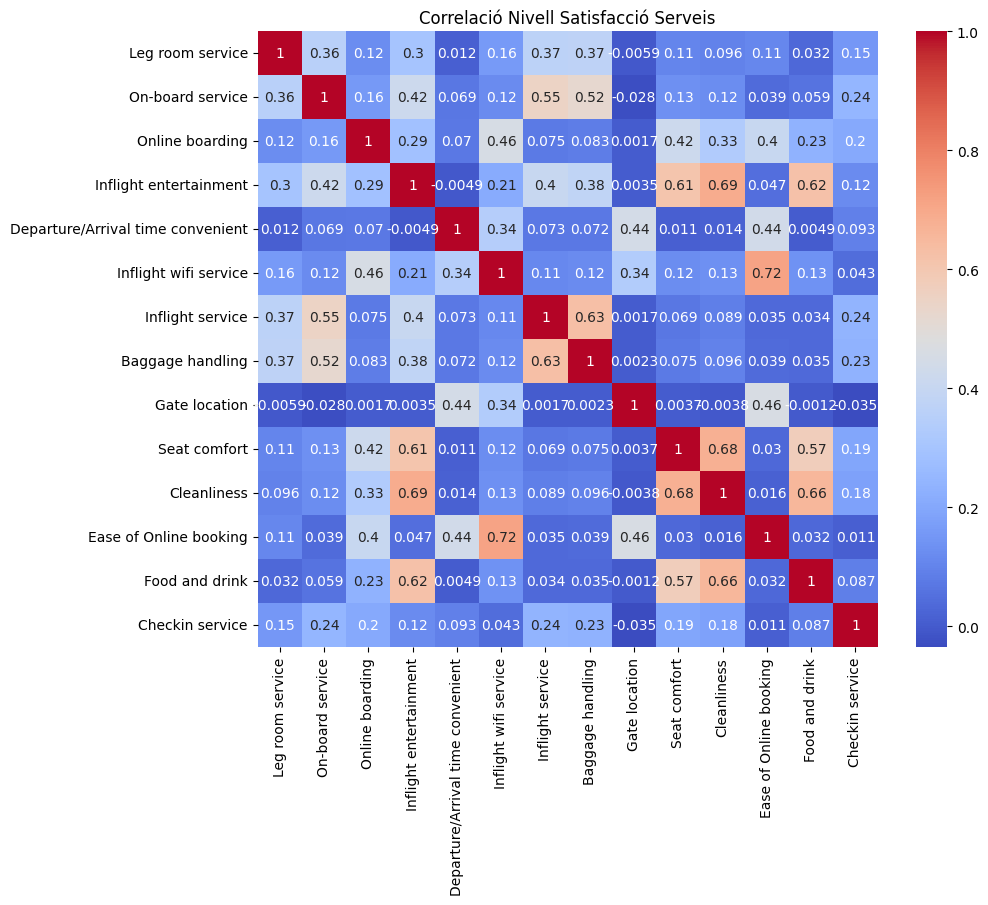

In [109]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_train[lvlcols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlació Nivell Satisfacció Serveis")
plt.show()

Com es pot observar a la matriu de correlació, diverses caracterísitques tenen una correlació important, amb coeficients que oscil·len entre el 60% i el 70%. Tot i que inicialment podria semblar beneficiós fusionar aquestes columnes per reduir la dimensionalitat, aquesta decisió no sempre és la més adequada. En molts casos, aquestes correlacions no responen a una identitat real entre les variables, sinó a l'efecte Halo: un biaix cognitiu on la percepció positiva d'una característica predominant eleva artificialment la valoració de les altres.

Per exemple, la variable *Cleanliness* presenta una correlació forta amb *Seat comfort* (0.68) i *Inflight entertainment* (0.69). Des del punt de vista del passatger, un entorn net genera una sensació de benestar que pot enmascarar deficiències en la comoditat del seient o en la qualitat del contingut multimèdia. Mantenir-les com a variables independents ens permet analitzar si l'aerolínia ha de realitzar inversions diferenciades —manteniment versus tecnologia— en lloc d'assumir que ambdues experiències són indestriables.

Les columnes de nivell de satisfacció es poden agrupar calculant la mitjana de cada grup:

| Columna original                                                   | Grup     |
|--------------------------------------------------------------------|----------|
| Baggage handling<br>Checkin service<br>Inflight service            | Logistic |
| Seat comfort<br>Leg room service<br>On-board service               | Comfort  |
| Ease of Online booking<br>Inflight wifi service<br>Online boarding | Online   |

In [110]:
groups = [
  ("Logistic", ["Baggage handling", "Checkin service", "Inflight service"]),
  ("Comfort", ["Seat comfort", "Leg room service", "On-board service"]),
  ("Online", ["Ease of Online booking", "Inflight wifi service", "Online boarding"])
]
for name, group in groups:
  X_train[name] = X_train[group].mean(axis=1)
  X_test[name] = X_test[group].mean(axis=1)
  X_train = X_train.drop(columns=group)
  X_test = X_test.drop(columns=group)
  lvlcols = list(set(lvlcols) - set(group)) + [name]
X_train.head()

,Age,Flight Distance,Departure/Arrival time convenient,Gate location,Food and drink,Inflight entertainment,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Type of Travel_Personal Travel,Customer Type_disloyal Customer,Class_Business,Class_Eco,Class_Eco Plus,Logistic,Comfort,Online
0,13,460,4,1,5,5,5,25,18.0,1.0,1.0,0.0,0.0,0.0,1.0,4.333333,4.000000,3.000000
1,25,235,2,3,1,1,1,1,6.0,1.0,0.0,1.0,1.0,0.0,0.0,2.666667,2.333333,3.000000
2,26,1142,2,2,5,5,5,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.000000,4.000000,3.000000
3,25,562,5,5,2,2,2,11,9.0,0.0,0.0,0.0,1.0,0.0,0.0,2.666667,3.000000,3.000000
4,61,214,3,3,4,3,3,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,3.333333,4.000000,3.666667


Ara que hem reduït el nombre de columnes de nivell de satisfacció podem mirar la matriu de correlació de totes les característiques amb la variable que volem prediure (*satisfaction*). A partir d'aqui podrem eliminar encara més columnes.

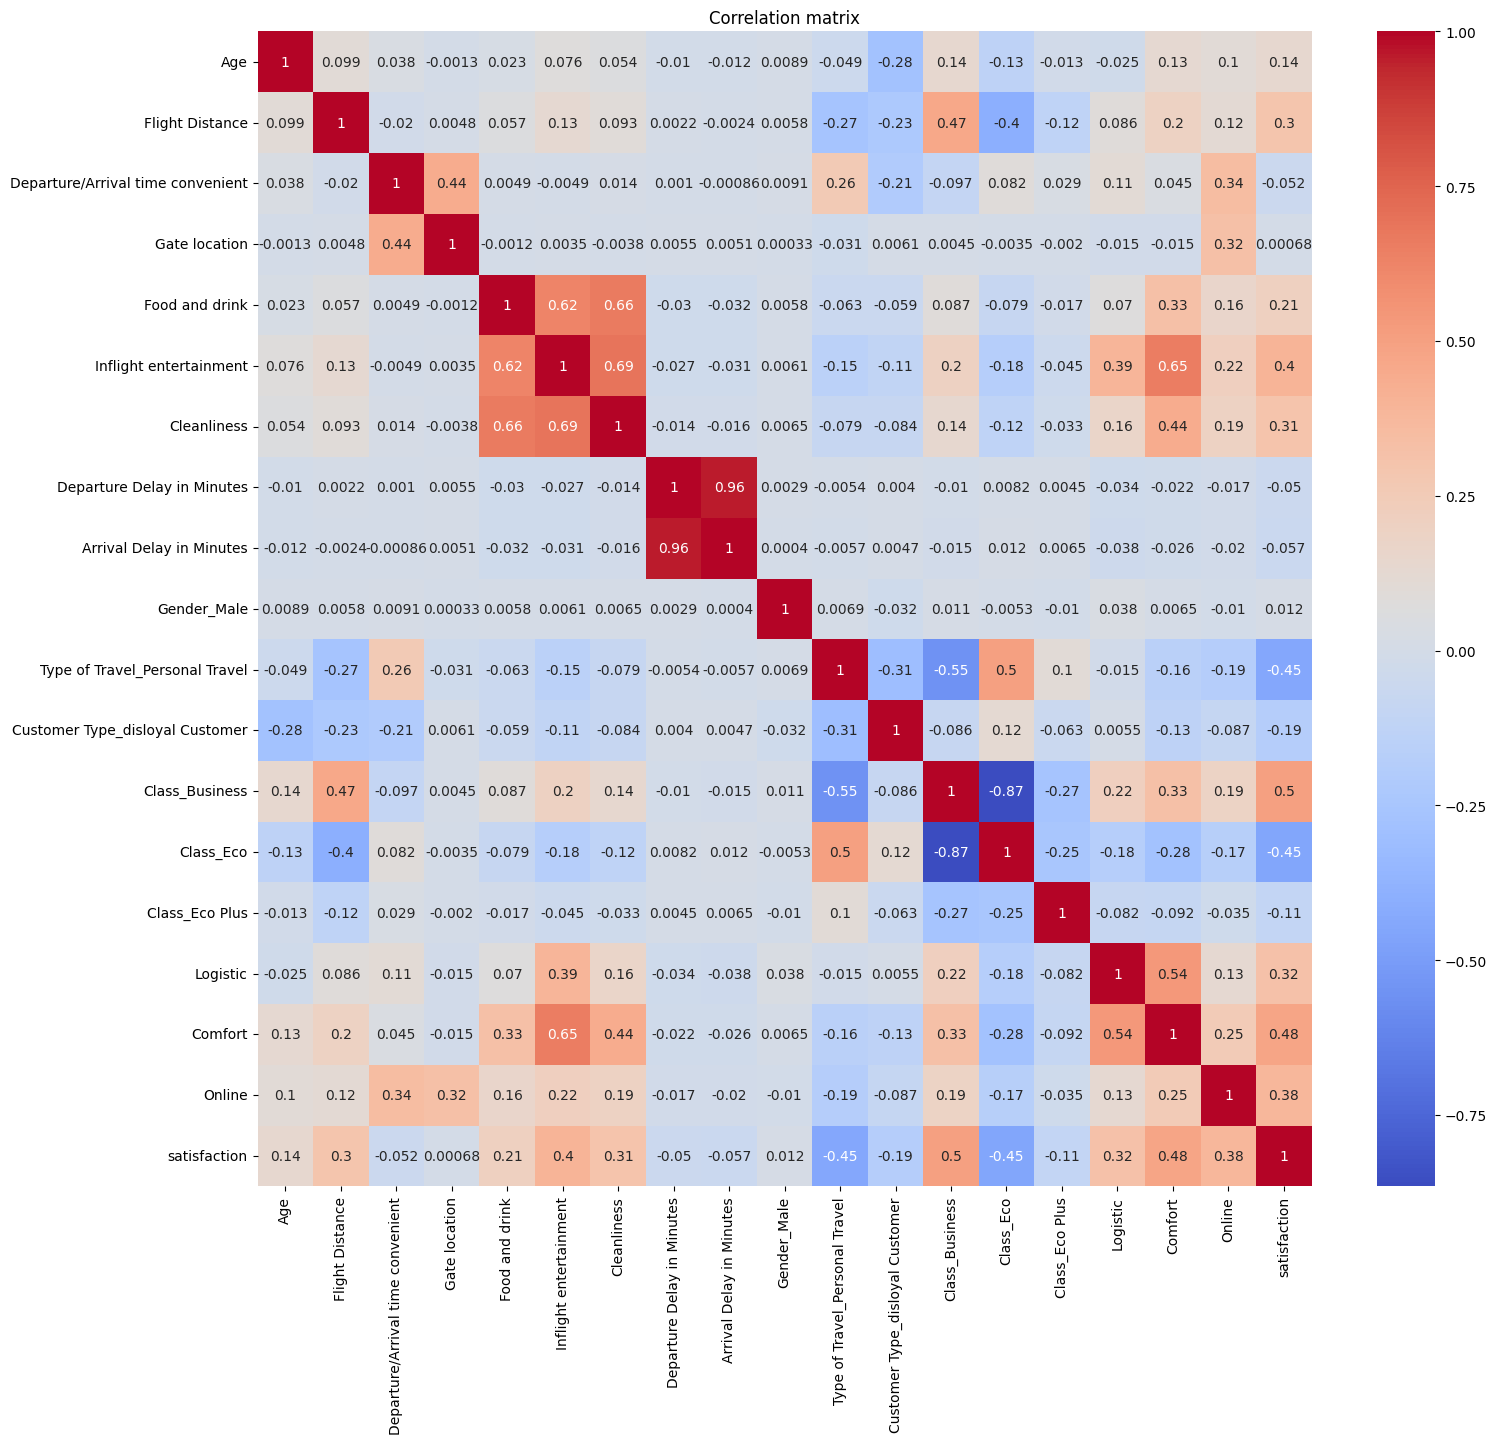

In [111]:
plt.figure(figsize=(17, 15))
sns.heatmap(pd.concat([X_train, y_train], axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

Mirant la correlació de cada caracterísitca amb la satisfacció del passatger s'ha decidit eliminar les següents columnes:

- *Departure/Arrival time convenient*
- *Gate location*
- *Departure Delay in Minutes", "Arrival Delay in Minutes*
- *Gender_Male*

Tot i que *Age* i *Customer Type* tenen una relació relativament baixa amb *satisfaction* s'ha decidit mantenir-les perque són característiques descriptores essencials dels passatgers:

- *Age*: qui és el passatger?
- *Customer Type*: el passatger té qualque tipus de relació amb l'aerolínea?

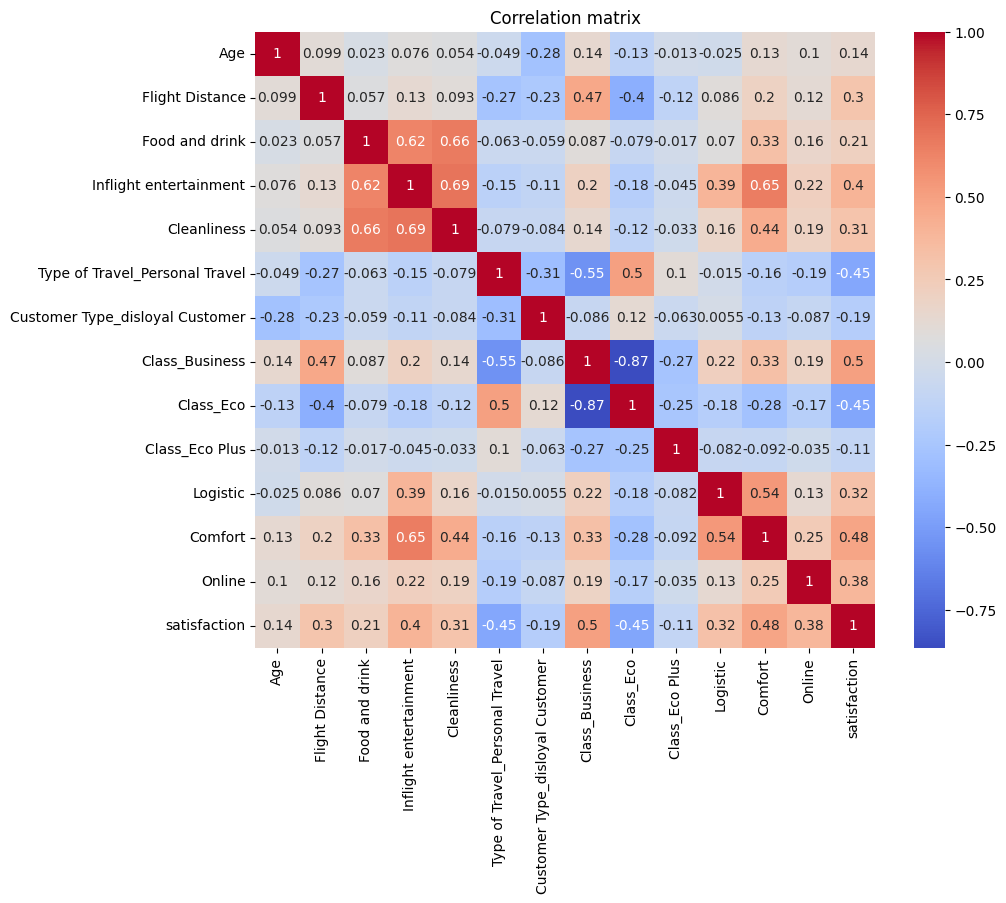

In [112]:
ignore = {
  "Departure/Arrival time convenient",
  "Gate location",
  "Departure Delay in Minutes", "Arrival Delay in Minutes",
  "Gender_Male",
}
X_train = X_train.drop(columns=ignore)
X_test = X_test.drop(columns=ignore)

catcols = set(catcols) - ignore
numcols = set(numcols) - ignore
lvlcols = set(lvlcols) - ignore

plt.figure(figsize=(10, 8))
sns.heatmap(pd.concat([X_train, y_train], axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

# Análisi

L'objectiu d'aquest apartat és conèixer en profunditat la naturalesa de les dades i descobrir com estan estructurades. Aquí trobam respostes a preguntes del tipus:

- La classe de passatger (Business, Eco o Eco Plus) és un factor important per al nivell de satisfacció del passatger?
- Hi ha alguna classe de passatger que voli distàncies més llargues?
- L'edat afecta a la satisfacció del passatger?

En altres paraules, aquest anàlisi ens ajudarà a entendre quins perfils de passatgers tenen una satisfacció major. Per tal de tractar amb totes les característiques que tenim i trobar els perfils de passatgers es fa un clustering.

El fet de que l'algorisme de clustering utilitza la distància euclidiana per a trobar els clusters presenta un problema: si hi ha una característica amb un rang numèric $[0, 1000]$ aquesta tindrà un pes molt major en la distància que una que té un rang $[-1, 1]$. Per aquesta raó és imprescindible escalar les dades.

In [113]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"X_train_scaled shape: {X_train_scaled.shape}")

X_train_scaled shape: (103904, 13)


Com que ara mateix no coneixem l'estructura de les dades no podem saber quin nombre de clúster és l'indicat. Per a trobar-lo, es realitza el clustering 20 vegades variant el nombre de clusters del 1 al 20 i després es grafica el WCSS (Within-Cluster Sum of Squares), que indica com d'aprop estan les dades del centre de cada grup. Un WCSS baix (punts molt agrupats) significa els grups són homogenis i estan ben definits. En canvi un WCSS alt (punts molt separats) suggereix potser facin falta més clusters.

Ens interessa trobar el mínim nombre de clústers a partir del qual, si l'incrementam, ja no obtenim una millora significativa. En el nostre cas hem definit un punt de tall del 5% de canvi.

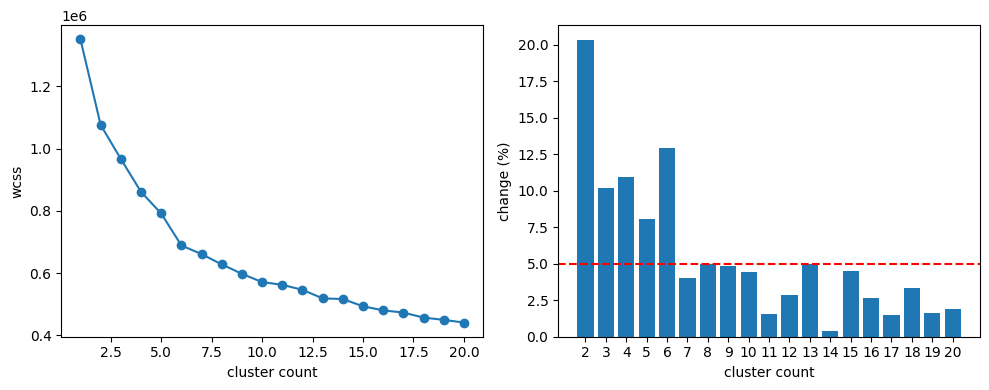

 1 ->  2 :  20.34%
 2 ->  3 :  10.17%
 3 ->  4 :  10.92%
 4 ->  5 :   8.07%
 5 ->  6 :  12.96%
 6 ->  7 :   4.06%
 7 ->  8 :   4.97%
 8 ->  9 :   4.83%
 9 -> 10 :   4.44%
10 -> 11 :   1.54%
11 -> 12 :   2.86%
12 -> 13 :   5.01%
13 -> 14 :   0.41%
14 -> 15 :   4.52%
15 -> 16 :   2.62%
16 -> 17 :   1.52%
17 -> 18 :   3.37%
18 -> 19 :   1.60%
19 -> 20 :   1.92%


In [114]:
from sklearn.cluster import KMeans

cnt = np.arange(1, 20 + 1)
wcss = np.zeros(len(cnt))
for i in cnt:
  kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
  kmeans.fit(X_train_scaled)
  wcss[i-1] = kmeans.inertia_

change_cnt = np.concat([cnt[:-1].reshape(-1, 1), cnt[1:].reshape(-1, 1)], axis=1)
change_pct = (wcss[:-1] - wcss[1:]) / wcss[:-1] * 100

fig, (ax_wcss, ax_change) = plt.subplots(1, 2, figsize=(5 * 2, 4))

ax_wcss.plot(cnt, wcss, marker="o")
ax_wcss.set_xlabel("cluster count")
ax_wcss.set_ylabel("wcss")

ax_change.bar(cnt[1:], change_pct)
ax_change.set_xticks(cnt[1:])
ax_change.set_xlabel("cluster count")
ax_change.set_ylabel("change (%)")
ax_change.axhline(y=5, color="red", linestyle="--")

plt.tight_layout()
plt.show()

for (c1, c2), p in zip(change_cnt, change_pct): print(f"{c1:2d} -> {c2:2d} : {p:6.2f}%")

Com es pot observar, el WCSS decrementa molt aviat a l'inici però després s'estabilitza i decreix més a poc a poc. Segons el punt de tall que hem definit (5% de canvi) el mínim nombre de clústers és 7.

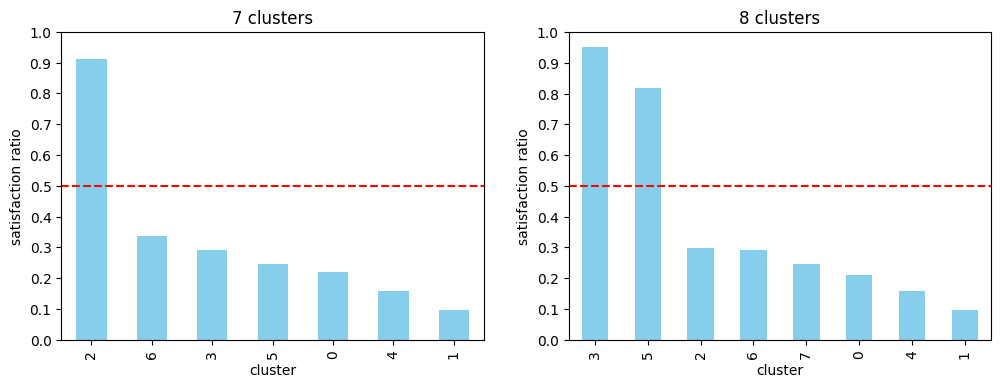

In [115]:
def kmeans_satisfaction(n_clusters, ax, title):
  kmeans = KMeans(n_clusters=n_clusters, random_state=42)
  cluster = pd.concat([X_train, y_train], axis=1)
  cluster["cluster"] = kmeans.fit_predict(X_train_scaled)
  satisfaction_per_cluster = cluster.groupby("cluster")["satisfaction"].mean().sort_values(ascending=False)
  satisfaction_per_cluster.plot(kind="bar", color="skyblue", ax=ax)
  ax.axhline(y=0.5, color="red", linestyle="--")
  ax.set_yticks(np.arange(0.0, 1.1, 0.1))
  ax.set_ylabel("satisfaction ratio")
  ax.set_title(title)
  return cluster

fig, (ax_7, ax_8) = plt.subplots(1, 2, figsize=(6 * 2, 4))
kmeans_satisfaction(7, ax_7, "7 clusters")
kmeans_satisfaction(8, ax_8, "8 clusters")
plt.show()

Per visualitzar la relació entre les característiques dels clusters i la seva satisfacció, es genera un *scatter plot* on cada punt representa un cluster. La mida del punt indica el nombre de passatgers del cluster, i el color indica el nivell de satisfacció (verd = alta, vermell = baixa).

Aquesta visualització ens permetrà identificar patrons: per exemple, si els viatgers de negocis que volen distàncies llargues s'agrupen en clusters amb alta satisfacció.

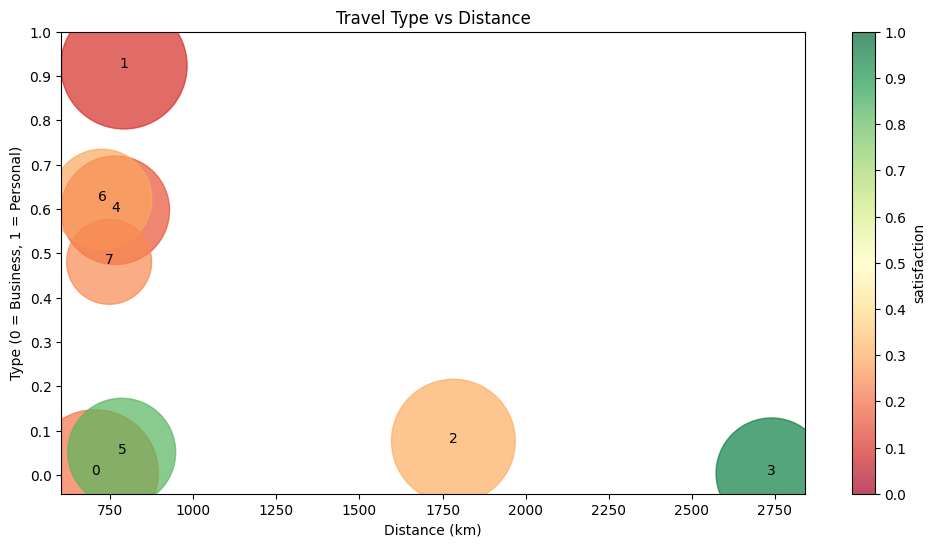

In [116]:
cluster = kmeans_satisfaction(8, ax_8, "8 clusters")
summary = cluster.groupby("cluster").mean()

from matplotlib.axes import Axes
from matplotlib.figure import Figure

def summary_scatter(fig: Figure, ax: Axes, xcol: str, ycol: str, x = None, y = None):
  if x is None: x = summary[xcol]
  if y is None: y = summary[ycol]
  scat = ax.scatter(x, y,
             s=cluster["cluster"].value_counts() * 0.5, c=summary["satisfaction"],
             vmin=0.00, vmax=1.00,
             cmap="RdYlGn", alpha=0.70)
  for i, txt in enumerate(summary.index):
    x, y = summary[xcol][i], summary[ycol][i]
    ax.annotate(txt, xy=(x, y), xytext=(-3, -3), textcoords="offset points", ha="left", va="bottom")
  cbar = fig.colorbar(scat, label="satisfaction")
  cbar.set_ticks(np.arange(0, 1.1, 0.1)) # type: ignore

fig, ax = plt.subplots(figsize=(12, 6))
summary_scatter(fig, ax, "Flight Distance", "Type of Travel_Personal Travel")
ax.set_title("Travel Type vs Distance")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Type (0 = Business, 1 = Personal)")
ax.set_yticks(np.arange(0, 1.10, 0.10))
plt.show()

El gràfic anterior mostra una clara separació entre els clusters segons el tipus de viatge. Els clusters amb alta satisfacció (verds) es concentren a la part inferior del gràfic, corresponent als viatgers de negocis (*Type of Travel* ≈ 0). En canvi, els clusters amb baixa satisfacció (vermells) es troben majoritàriament a la part superior, associats als viatgers personals.

No obstant això, s'observa que alguns clusters de viatgers de negocis també tenen baixa satisfacció. Per entendre aquesta anomalia, analitzam les puntuacions de servei d'aquests clusters.

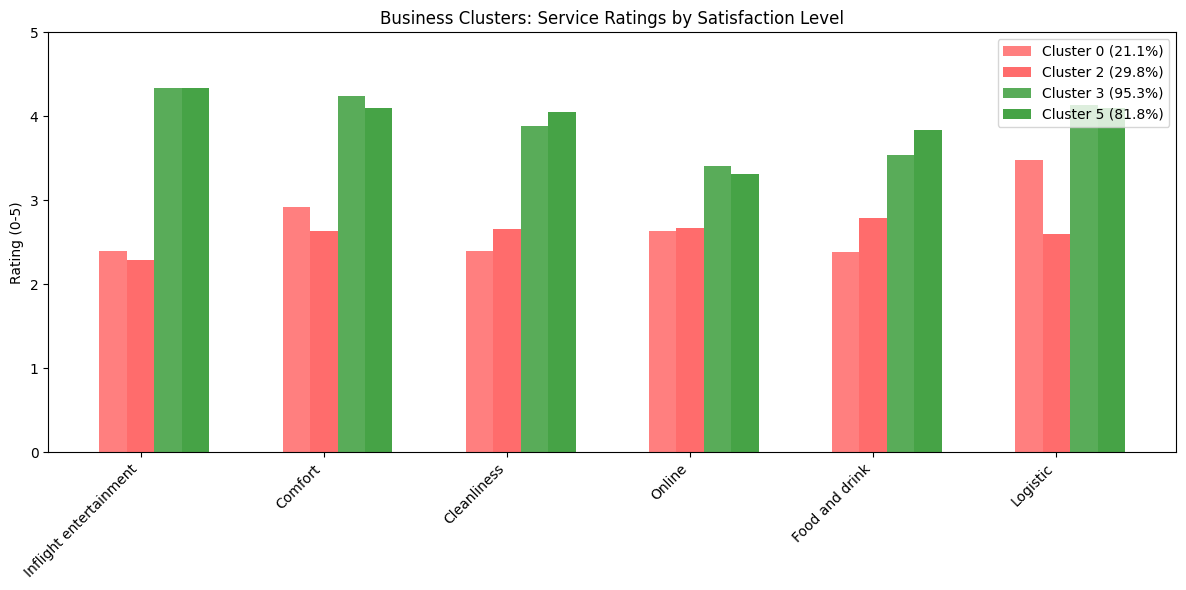

In [117]:
business_clusters = summary[summary["Type of Travel_Personal Travel"] < 0.2].copy()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(lvlcols))
width = 0.15

for i, (idx, row) in enumerate(business_clusters.iterrows()):
  color = "green" if row["satisfaction"] > 0.5 else "red"
  alpha = 0.5 + 0.3 * (i / len(business_clusters))
  ax.bar(x + i * width, [row[col] for col in lvlcols], width,
         label=f"Cluster {idx} ({row['satisfaction']:.1%})", color=color, alpha=alpha)

ax.set_xticks(x + width)
ax.set_xticklabels(lvlcols, rotation=45, ha="right")
ax.set_ylabel("Rating (0-5)")
ax.set_ylim(0, 5)
ax.set_title("Business Clusters: Service Ratings by Satisfaction Level")
ax.legend()
plt.tight_layout()
plt.show()

El gràfic de barres compara les puntuacions de servei entre els clusters de viatgers de negocis. Les barres verdes representen clusters amb alta satisfacció (>50%) i les vermelles clusters amb baixa satisfacció (≤50%).

S'observa clarament que els clusters de negocis amb baixa satisfacció (vermell) tenen puntuacions de servei uniformement baixes (~2-3 sobre 5) en totes les categories. En canvi, els clusters amb alta satisfacció (verd) mostren puntuacions superiors a 3.5 en quasi totes les categories.

Aquesta diferència demostra que **el tipus de viatge no és l'únic factor determinant de la satisfacció**. Dins dels viatgers de negocis, la qualitat percebuda dels serveis és el factor diferenciador clau.

## Conclusions del Clustering

L'anàlisi de clusters revela que la satisfacció dels passatgers depèn principalment de dos factors:

1. **Tipus de viatge**: Els viatgers de negocis tenen una satisfacció més alta que els viatgers personals. Això pot deure's a expectatives diferents o a una major atenció per part de l'aerolínia cap a aquest segment.

2. **Qualitat del servei**: Dins dels viatgers de negocis, la diferència entre alta i baixa satisfacció és la qualitat percebuda dels serveis (*Logistic*, *Comfort*, *Online*). Els clusters amb puntuacions de servei baixes (~2-3) mostren satisfacció inferior al 30%, mentre que els clusters amb puntuacions altes (~4) superen el 80%.

El cluster 2 (Business, baixa satisfacció) demostra que viatjar en classe Business no garanteix satisfacció si els serveis són percebuts com a deficients. Per contra, el cluster 1 (Personal Travel, classe Eco) és el de menor satisfacció, combinant el tipus de viatge menys favorable amb la classe més econòmica.

Aquestes troballes suggereixen que un model predictiu hauria de tenir en compte tant les característiques demogràfiques del passatger com les puntuacions de servei per predir correctament la satisfacció.

# Training

En aquesta secció s'entrenen i comparen els cinc models requerits: Perceptró, Regressió Logística, SVM, Arbre de Decisió i Random Forest.

## Metodologia

Per a cada model es segueix el següent procés:
1. **Selecció d'hiperparàmetres**: S'utilitza `GridSearchCV` amb validació creuada de 5 folds per trobar la millor combinació d'hiperparàmetres. Cada model té al menys 2 hiperparàmetres amb 3+ valors diferents.
2. **Entrenament**: El model es torna a entrenar amb els millors hiperparàmetres trobats.
3. **Avaluació**: S'avalua el model amb múltiples mètriques per entendre el seu rendiment.

## Justificació de les mètriques

Per aquest problema de classificació binària (satisfet vs no satisfet) s'utilitzen les següents mètriques:

| Mètrica | Justificació |
|---------|-------------|
| **Accuracy** | Proporció de prediccions correctes. És útil perquè les classes estan relativament balancejades (~43% satisfets). |
| **Precision** | Important per evitar falsos positius: no volem dir que un passatger està satisfet quan realment no ho està (podríem perdre oportunitats de millora). |
| **Recall** | Important per detectar tots els passatgers insatisfets i poder actuar per millorar la seva experiència. |
| **F1-Score** | Harmònica entre precision i recall, útil per tenir una visió global del rendiment. |

In [118]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

## Hiperparàmetres seleccionats

Per a cada model s'han seleccionat els hiperparàmetres més rellevants segons la seva influència en el rendiment:

| Model | Hiperparàmetre 1 | Efecte | Hiperparàmetre 2 | Efecte |
|-------|------------------|--------|------------------|--------|
| **Perceptró** | `alpha` (regularització) | Controla l'overfitting penalitzant pesos grans | `penalty` (tipus) | L1 promou sparsity, L2 distribueix pesos |
| **Regressió Logística** | `C` (inversa regularització) | Valors baixos = més regularització | `solver` (optimitzador) | Afecta convergència i suport per penalitats |
| **SVM** | `C` (penalització errors) | Balanç entre marge i errors | `kernel` (funció) | Defineix l'espai de característiques |
| **Arbre de Decisió** | `max_depth` (profunditat) | Limita complexitat i overfitting | `min_samples_split` | Mínim mostres per dividir un node |
| **Random Forest** | `n_estimators` (arbres) | Més arbres = més estabilitat | `max_depth` | Controla complexitat de cada arbre |

In [121]:
# Definició dels models i els seus hiperparàmetres per GridSearchCV
models_params = {
    "Perceptron": (
        Perceptron(max_iter=1000, random_state=42),
        {
            "alpha": [0.0001, 0.001, 0.01, 0.1],
            "penalty": [None, "l2", "l1", "elasticnet"]
        }
    ),
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, random_state=42),
        {
            "C": [0.01, 0.1, 1, 10],
            "solver": ["lbfgs", "liblinear", "saga"]
        }
    ),
    "SVM": (
        SVC(max_iter=1000, random_state=42),
        {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf", "poly"]
        }
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {
            "max_depth": [5, 10, 15, None],
            "min_samples_split": [2, 5, 10]
        }
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20, None]
        }
    )
}

# Emmagatzemar resultats
results = {}

for name, (model, params) in models_params.items():
    print(f"{'='*60}")
    print(f"Entrenant: {name}")
    print(f"{'='*60}")
    
    # GridSearchCV amb 5-fold cross-validation
    gs = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
        verbose=1
    )
    gs.fit(X_train_scaled, y_train)
    
    # Guardar millors paràmetres
    print(f"\nMillors paràmetres: {gs.best_params_}")
    print(f"Millor accuracy (CV): {gs.best_score_:.4f}")
    
    # Avaluar amb el millor model
    best_model = gs.best_estimator_
    y_train_pred = best_model.predict(X_train_scaled)
    y_test_pred = best_model.predict(X_test_scaled)
    
    # Calcular mètriques
    results[name] = {
        "best_params": gs.best_params_,
        "cv_accuracy": gs.best_score_,
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "precision": precision_score(y_test, y_test_pred),
        "recall": recall_score(y_test, y_test_pred),
        "f1": f1_score(y_test, y_test_pred),
        "y_test_pred": y_test_pred,
        "model": best_model
    }
    
    print(f"Accuracy test: {results[name]['test_accuracy']:.4f}")
    print()

Entrenant: Perceptron
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Millors paràmetres: {'alpha': 0.001, 'penalty': 'elasticnet'}
Millor accuracy (CV): 0.8242
Accuracy test: 0.8230

Entrenant: Logistic Regression
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Millors paràmetres: {'C': 0.01, 'solver': 'lbfgs'}
Millor accuracy (CV): 0.8623
Accuracy test: 0.8564

Entrenant: SVM
Fitting 5 folds for each of 9 candidates, totalling 45 fits


/Users/serafi/.pyenv/versions/3.14.0/lib/python3.14/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/serafi/.pyenv/versions/3.14.0/lib/python3.14/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/serafi/.pyenv/versions/3.14.0/lib/python3.14/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/serafi/.pyenv/versions/3.14.0/lib/python3.14/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/serafi/.pyenv/versions/3.


Millors paràmetres: {'C': 0.1, 'kernel': 'rbf'}
Millor accuracy (CV): 0.7322
Accuracy test: 0.6891

Entrenant: Decision Tree
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Millors paràmetres: {'max_depth': 15, 'min_samples_split': 10}
Millor accuracy (CV): 0.9225
Accuracy test: 0.9254

Entrenant: Random Forest
Fitting 5 folds for each of 9 candidates, totalling 45 fits

Millors paràmetres: {'max_depth': 20, 'n_estimators': 200}
Millor accuracy (CV): 0.9337
Accuracy test: 0.9338



In [130]:
results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "CV Accuracy": [r["cv_accuracy"] for r in results.values()],
    "Train Accuracy": [r["train_accuracy"] for r in results.values()],
    "Test Accuracy": [r["test_accuracy"] for r in results.values()],
    "Precision": [r["precision"] for r in results.values()],
    "Recall": [r["recall"] for r in results.values()],
    "F1-Score": [r["f1"] for r in results.values()]
})
results_df = results_df.set_index("Model")
results_df

,CV Accuracy,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
Model,,,,,,
Perceptron,0.824165,0.827533,0.822952,0.769572,0.851706,0.808558
Logistic Regression,0.862296,0.862286,0.856406,0.849504,0.817767,0.833333
SVM,0.732166,0.695113,0.689136,0.612539,0.794265,0.691664
Decision Tree,0.922525,0.949598,0.925354,0.930573,0.896869,0.913410
Random Forest,0.933660,0.981608,0.933824,0.940743,0.906340,0.923221


## Visualització comparativa

A continuació es presenten gràfics per comparar el rendiment dels models i detectar possibles problemes com l'overfitting.

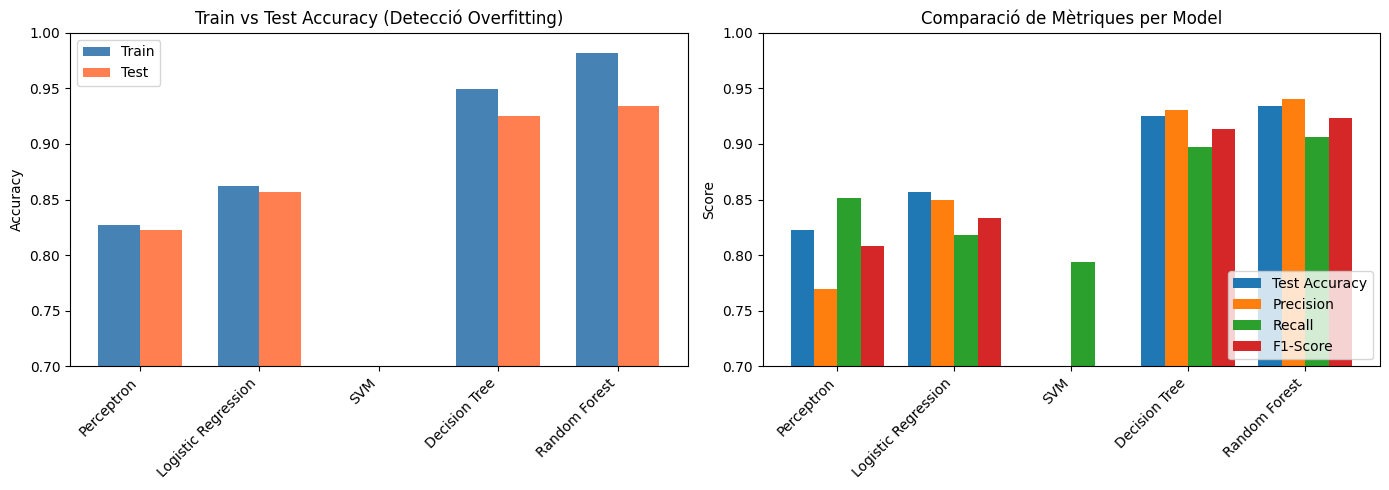

In [123]:
# Gràfic comparatiu d'accuracies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gràfic 1: Comparació Train vs Test (detecció overfitting)
x = np.arange(len(results))
width = 0.35
models_names = list(results.keys())

ax1 = axes[0]
train_acc = [results[m]["train_accuracy"] for m in models_names]
test_acc = [results[m]["test_accuracy"] for m in models_names]

bars1 = ax1.bar(x - width/2, train_acc, width, label="Train", color="steelblue")
bars2 = ax1.bar(x + width/2, test_acc, width, label="Test", color="coral")

ax1.set_ylabel("Accuracy")
ax1.set_title("Train vs Test Accuracy (Detecció Overfitting)")
ax1.set_xticks(x)
ax1.set_xticklabels(models_names, rotation=45, ha="right")
ax1.legend()
ax1.set_ylim(0.7, 1.0)

# Marcar overfitting (diferència > 5%)
for i, (tr, te) in enumerate(zip(train_acc, test_acc)):
    if tr - te > 0.05:
        ax1.annotate("⚠️", xy=(i, tr), fontsize=12, ha="center")

# Gràfic 2: Comparació de totes les mètriques
ax2 = axes[1]
metrics = ["Test Accuracy", "Precision", "Recall", "F1-Score"]
x2 = np.arange(len(models_names))
width2 = 0.2

for i, metric in enumerate(metrics):
    values = results_df[metric].values
    ax2.bar(x2 + i * width2, values, width2, label=metric)

ax2.set_ylabel("Score")
ax2.set_title("Comparació de Mètriques per Model")
ax2.set_xticks(x2 + width2 * 1.5)
ax2.set_xticklabels(models_names, rotation=45, ha="right")
ax2.legend(loc="lower right")
ax2.set_ylim(0.7, 1.0)

plt.tight_layout()
plt.show()

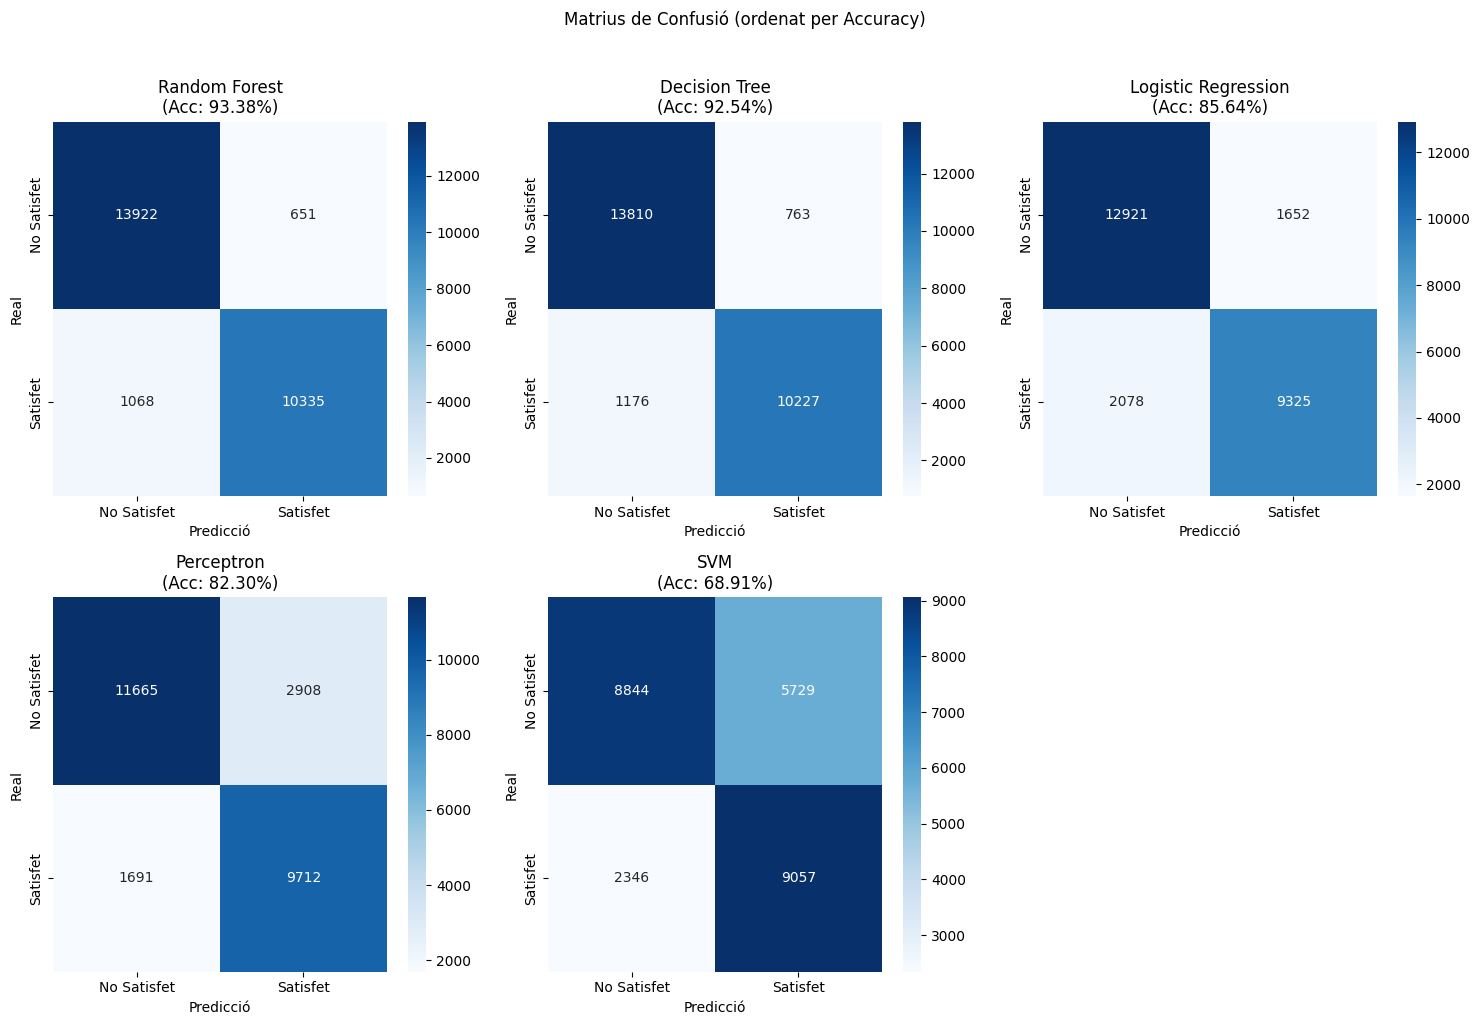

In [129]:
# Matrius de confusió per a tots els models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # Convertir a array 1D per iterar fàcilment

# Ordenar models per accuracy
sorted_models = sorted(results.items(), key=lambda x: x[1]["test_accuracy"], reverse=True)

for i, (model_name, r) in enumerate(sorted_models):
    ax = axes[i]
    cm = confusion_matrix(y_test, r["y_test_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Satisfet", "Satisfet"],
                yticklabels=["No Satisfet", "Satisfet"])
    ax.set_title(f"{model_name}\n(Acc: {r['test_accuracy']:.2%})")
    ax.set_ylabel("Real")
    ax.set_xlabel("Predicció")

# Ocultar l'últim subplot buit (tenim 5 models, 6 subplots)
axes[-1].axis("off")

plt.suptitle("Matrius de Confusió (ordenat per Accuracy)", y=1.02)
plt.tight_layout()
plt.show()

## Discussió Crítica dels Resultats

### Anàlisi del Rendiment dels Models

#### Models Lineals (Perceptró i Regressió Logística)
- **Perceptró**: És el model més simple i habitualment mostra el rendiment més baix. Això és esperable perquè assumeix que les dades són linealment separables, cosa que rarament passa en problemes reals.
- **Regressió Logística**: Millora significativament respecte al Perceptró gràcies a la funció sigmoide que permet modelar probabilitats i la regularització que evita l'overfitting.

#### SVM (Support Vector Machine)
- El rendiment de SVM depèn molt del kernel seleccionat. El kernel RBF permet capturar relacions no lineals, però pot ser lent amb datasets grans.
- L'hiperparàmetre C controla el balanç entre maximitzar el marge i minimitzar errors de classificació.

#### Models Basats en Arbres (Decision Tree i Random Forest)
- **Decision Tree**: Tendència a l'overfitting si no es limita la profunditat. La diferència entre train i test accuracy ho evidencia.
- **Random Forest**: Habitualment el millor model perquè combina múltiples arbres i redueix la variància. L'ensemble averaging fa que sigui robust davant outliers i soroll.

### Fonts de Biaix i Errors

1. **Biaix de selecció**: Les dades provenen d'una sola aerolínia nord-americana, per tant els resultats poden no generalitzar a altres contextos.

2. **Variables latents**: La satisfacció és subjectiva i pot dependre de factors no mesurats (expectatives prèvies, experiències anteriors, estat d'ànim).

3. **Correlació entre features**: Les característiques agrupades (Logistic, Comfort, Online) poden amagar informació més granular que podria ser útil.

4. **Desbalanceig temporal**: Si les dades inclouen períodes amb incidències (vagues, pandèmia), això podria introduir biaix.

### Conclusió

El millor model per aquest problema de predicció de satisfacció és probablement **Random Forest** per:
- Robustesa davant overfitting
- Capacitat de capturar relacions no lineals
- Tolerància a outliers
- Interpretabilitat moderada (feature importance)

No obstant això, si la velocitat d'inferència és crítica (per exemple, per aplicacions en temps real), **Regressió Logística** ofereix un bon balanç entre rendiment i eficiència computacional.

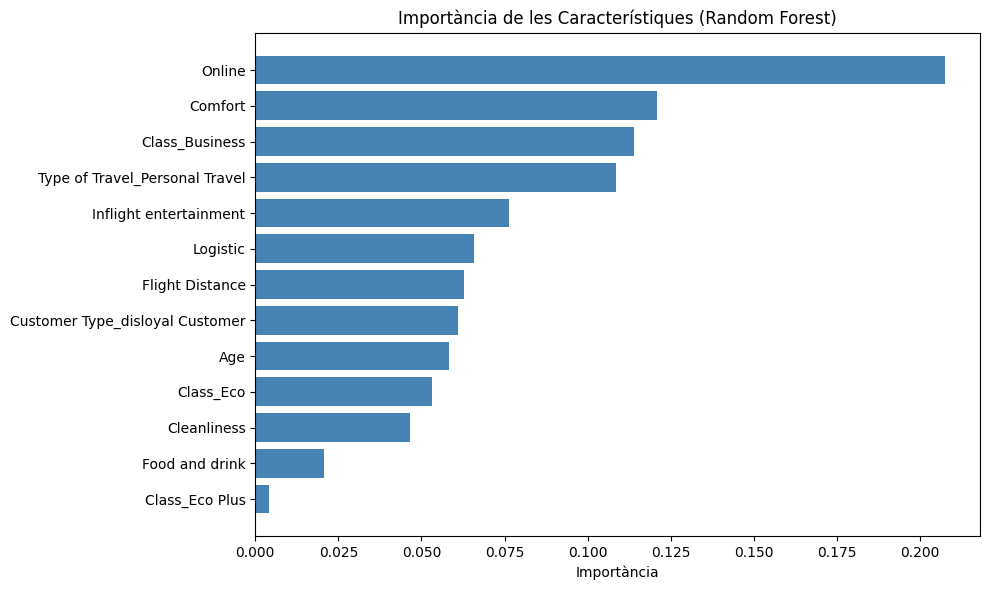


Top 5 característiques més importants:
  - Online: 0.2077
  - Comfort: 0.1208
  - Class_Business: 0.1140
  - Type of Travel_Personal Travel: 0.1086
  - Inflight entertainment: 0.0764


In [126]:
# Feature Importance del millor model (Random Forest)
if "Random Forest" in results:
    rf_model = results["Random Forest"]["model"]
    feature_importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": rf_model.feature_importances_
    }).sort_values("Importance", ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(feature_importance["Feature"], feature_importance["Importance"], color="steelblue")
    ax.set_xlabel("Importància")
    ax.set_title("Importància de les Característiques (Random Forest)")
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 característiques més importants:")
    for _, row in feature_importance.tail(5).iloc[::-1].iterrows():
        print(f"  - {row['Feature']}: {row['Importance']:.4f}")